## 1. Carga de librerías

Se importan las librerías necesarias para cargar modelos, calcular métricas y generar gráficos de evaluación.

In [5]:
# Librerías principales
import pandas as pd
import numpy as np
import joblib
import os

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Carga de datos y particiones train/test

Se cargan las particiones de entrenamiento y prueba guardadas en el notebook anterior. Así se mantiene la misma separación de datos usada durante el entrenamiento de los modelos base.

In [6]:
# Cargamos los datos usados para clasificación
classification_data = joblib.load("../results/metrics/classification_train_test_data.pkl")

X_train_clf = classification_data["X_train"]
X_test_clf = classification_data["X_test"]
y_train_clf = classification_data["y_train"]
y_test_clf = classification_data["y_test"]

In [7]:
# Rutas de los modelos guardados
classification_model_paths = {
    "Logistic Regression": "../models/trained_models/logistic_regression_classification_base.pkl",
    "Decision Tree": "../models/trained_models/decision_tree_classification_base.pkl",
    "Random Forest": "../models/trained_models/random_forest_classification_base.pkl"
}

# Cargamos los modelos
classification_models = {
    name: joblib.load(path)
    for name, path in classification_model_paths.items()
}

classification_models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest'])

## 3. Cálculo de métricas base

Se calculan métricas principales para comparar los modelos: accuracy, precision, recall y F1-score.

In [8]:
# Evaluamos cada modelo con métricas base
classification_results = []

for name, model in classification_models.items():
    y_pred = model.predict(X_test_clf)

    classification_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_clf, y_pred),
        "precision": precision_score(y_test_clf, y_pred, zero_division=0),
        "recall": recall_score(y_test_clf, y_pred, zero_division=0),
        "f1_score": f1_score(y_test_clf, y_pred, zero_division=0)
    })

classification_metrics_df = pd.DataFrame(classification_results)

classification_metrics_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.990431,0.925926,0.862069,0.892857
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000


## 4. Guardado de métricas

Se guarda la tabla de métricas para usarla en el informe y en la comparación posterior.

In [9]:
# Guardamos métricas base
classification_metrics_df.to_csv(
    "../results/metrics/classification_base_metrics.csv",
    index=False
)

## 5. Comparación de modelos según F1-score

Se grafica el F1-score de cada modelo. Esta métrica sirve para comparar el equilibrio entre precision y recall.

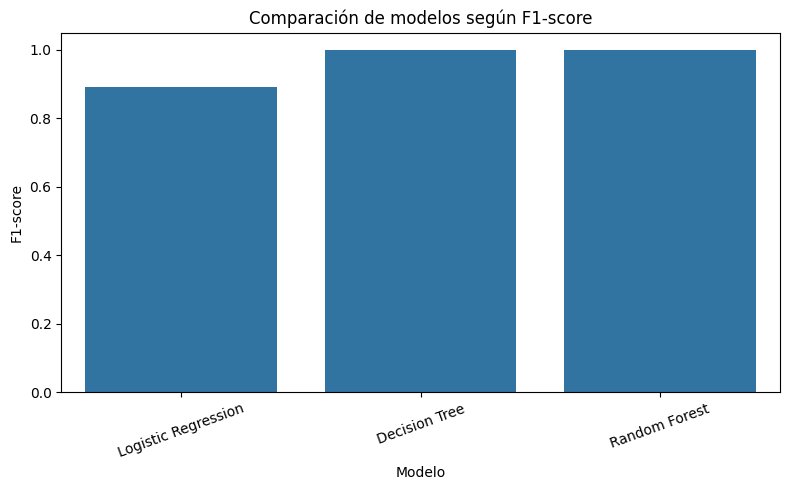

In [10]:
# Gráfico de F1-score por modelo
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics_df,
    x="model",
    y="f1_score"
)

plt.title("Comparación de modelos según F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../results/plots/classification_f1_comparison.png")
plt.show()

Los modelos basados en árboles obtuvieron un F1-score muy alto, incluso después de retirar variables que podían entregar pistas demasiado directas, como `conflict_phase`, `origin_city` y `destination_city`.

Esto puede indicar que el dataset tiene patrones bastante marcados entre variables como aerolínea, costos, pasajeros y disrupción. Por eso, este resultado no se interpreta como conclusión definitiva, sino como una primera comparación de modelos base. La estabilidad del rendimiento debería revisarse después con validación cruzada.

## 6. Selección del modelo base

Como Random Forest tuvo uno de los mejores resultados y suele ser más estable que un solo árbol, se deja como modelo base principal para revisar con más detalle.

In [11]:
# Seleccionamos Random Forest como modelo base principal
best_clf_name = "Random Forest"
best_clf_model = classification_models[best_clf_name]

print("Modelo seleccionado:", best_clf_name)

Modelo seleccionado: Random Forest


## 7. Matriz de confusión

Revisamos la matriz de confusión para ver en qué casos el modelo acierta y en cuáles se equivoca.

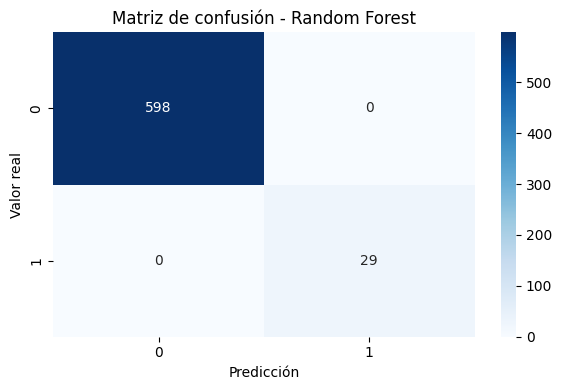

In [12]:
# Predicciones del modelo seleccionado
y_pred_best = best_clf_model.predict(X_test_clf)

# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_best)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Matriz de confusión - {best_clf_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()

plt.savefig("../results/plots/confusion_matrix_best_model.png")
plt.show()

El modelo logra clasificar muy bien los casos del conjunto de prueba. Aun así, como el resultado es muy alto, no se toma como conclusión final todavía.

La validación cruzada servirá para revisar si este rendimiento se mantiene con otras particiones de los datos.

## 8. Reporte de clasificación

Se revisan las métricas por clase para ver mejor el comportamiento del modelo.

In [13]:
# Reporte detallado del modelo seleccionado
print(classification_report(y_test_clf, y_pred_best, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00        29

    accuracy                           1.00       627
   macro avg       1.00      1.00      1.00       627
weighted avg       1.00      1.00      1.00       627



La clase 0 corresponde a vuelos sin disrupción y la clase 1 a vuelos con disrupción.

Como la clase 1 tiene muchos menos casos en el conjunto de prueba, es importante revisar su recall y F1-score, no solo el accuracy general. En esta primera evaluación el rendimiento es perfecto, pero debe confirmarse después con validación cruzada.

## 9. Registro del modelo seleccionado

Se guarda el nombre del modelo base seleccionado para usarlo como referencia en la siguiente etapa.

In [14]:
# Guardamos el nombre del modelo seleccionado
with open("../results/metrics/best_base_model.txt", "w") as file:
    file.write(best_clf_name)

print("Modelo base seleccionado guardado.")

Modelo base seleccionado guardado.


## 10. Validación cruzada

En esta parte se revisa si el rendimiento de los modelos se mantiene usando distintas particiones de los datos. Para eso se usa validación cruzada con F1-score como métrica principal.

In [15]:
# Importamos validación cruzada
from sklearn.model_selection import cross_val_score

# Evaluamos cada modelo con validación cruzada
cv_results = []

for name, model in classification_models.items():
    scores = cross_val_score(
        model,
        X_train_clf,
        y_train_clf,
        cv=5,
        scoring="f1"
    )
    
    cv_results.append({
        "model": name,
        "cv_f1_mean": scores.mean(),
        "cv_f1_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,model,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.848412,0.027158
1,Decision Tree,0.995556,0.008889
2,Random Forest,0.995745,0.008511


## 11. Guardado de resultados de validación cruzada

Se guardan los resultados para usarlos después en el análisis final.

In [16]:
# Guardamos los resultados de validación cruzada
cv_results_df.to_csv(
    "../results/metrics/classification_cv_metrics.csv",
    index=False
)

## 12. Comparación con validación cruzada

Este gráfico permite comparar el F1 promedio obtenido por cada modelo en validación cruzada.

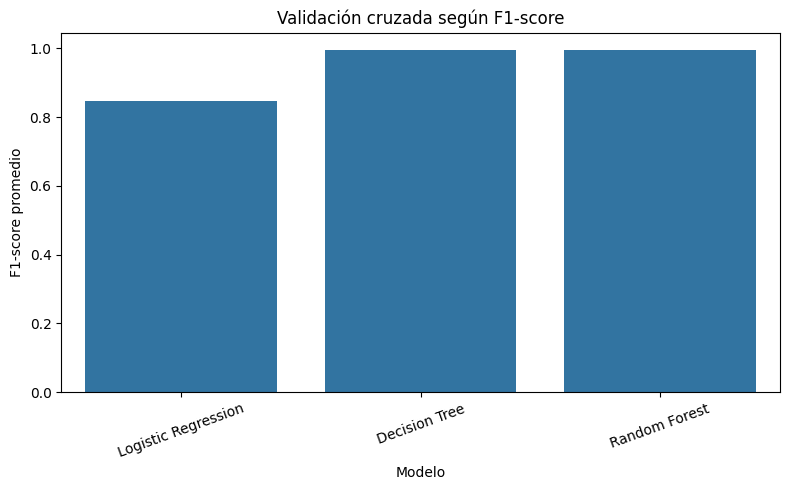

In [17]:
# Gráfico de F1 promedio en validación cruzada
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cv_results_df,
    x="model",
    y="cv_f1_mean"
)

plt.title("Validación cruzada según F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1-score promedio")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../results/plots/classification_cv_f1_comparison.png")
plt.show()

Los resultados permiten revisar si el rendimiento alto de los modelos se mantiene al cambiar las particiones de entrenamiento. Esto es importante porque una sola separación train/test puede mostrar un resultado demasiado optimista.

## 13. Comparación base vs validación cruzada

Se comparan los resultados obtenidos en la evaluación base con los resultados de validación cruzada.

In [18]:
# Unimos métricas base con métricas de validación cruzada
comparison_df = classification_metrics_df.merge(
    cv_results_df,
    on="model",
    how="left"
)

comparison_df

,model,accuracy,precision,recall,f1_score,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.990431,0.925926,0.862069,0.892857,0.848412,0.027158
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,0.995556,0.008889
2,Random Forest,1.000000,1.000000,1.000000,1.000000,0.995745,0.008511


In [19]:
# Guardamos comparación
comparison_df.to_csv(
    "../results/metrics/classification_base_vs_cv.csv",
    index=False
)

Esta comparación ayuda a ver si el mejor modelo base también se mantiene estable en validación cruzada. Si el rendimiento baja mucho, significa que el resultado inicial dependía demasiado de la partición train/test.

## 14. Cierre de evaluación de modelos

En este notebook se compararon los modelos base usando métricas principales y validación cruzada.

Random Forest queda como modelo principal para la siguiente etapa, porque obtuvo buen rendimiento en la evaluación base y será optimizado en el siguiente notebook.